# Frozen BridgeRNA sample-embedding readouts

This benchmark compares sample-level summaries from frozen Transformer layers 11 and 12. The encoder is never updated. Fixed summaries reuse cached hidden-state statistics; attention parameters are learned strictly inside each downstream study-disjoint training fold.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
HERE=Path.cwd()
if HERE.name!='frozen_sample_embedding_readout':
    HERE=HERE/'benchmarks/frozen_sample_embedding_readout'
RESULTS=HERE/'results'
pd.set_option('display.max_columns',100)

## Cohort and protocol

The cohort, sample order, tissue labels, and five GSE-disjoint folds are identical to the prior Task 4 tissue-generalization benchmark (3,272 samples; 14 tissues; 1,678 studies). Only layers 11 and 12 are examined. Attention readouts see labels only in the training partition of each outer fold.

In [2]:
provenance=json.loads((RESULTS/'provenance.json').read_text())
display(pd.Series(provenance,name='value').to_frame())

,value
encoder_frozen,True
layers,"[11, 12]"
folds,exact existing five GSE-disjoint folds
trainable_readouts,trained only within each downstream outer fold
epochs,8
note,Attention test-fold geometry is averaged withi...


## Ranked tissue-generalization results

layer,readout,dimensions,trainable_params,study_disjoint_f1,f1_sd,balanced_accuracy,PC1_2,participation_ratio,tissue_10nn_purity,study_10nn_purity
11,mean_plus_std,1024,0,0.8355,0.0338,0.8540,0.7261,2.3813,0.7554,0.0622
12,mean_plus_std,1024,0,0.8332,0.0254,0.8535,0.6788,2.7860,0.7614,0.0641
12,mean_plus_std_plus_max,1536,0,0.8277,0.0206,0.8324,0.4647,6.8018,0.8116,0.0731
11+12,mean_std_pca_projection,512,1049088,0.8246,0.0206,0.8441,0.6992,2.5997,0.6389,0.0761
11,mean_plus_std_plus_max,1536,0,0.8225,0.0280,0.8293,0.5045,5.3824,0.8124,0.0708
11,std,512,0,0.8146,0.0283,0.8406,0.5972,4.4571,0.7974,0.0723
12,std,512,0,0.8128,0.0261,0.8350,0.5588,5.0995,0.7928,0.0731
12,expression_weighted_mean,512,0,0.8021,0.0234,0.8359,0.6651,3.0551,0.7609,0.0656
11,expression_weighted_mean,512,0,0.8021,0.0252,0.8342,0.7102,2.5336,0.7683,0.0670
12,mean,512,0,0.8019,0.0303,0.8361,0.6887,2.6779,0.7737,0.0663


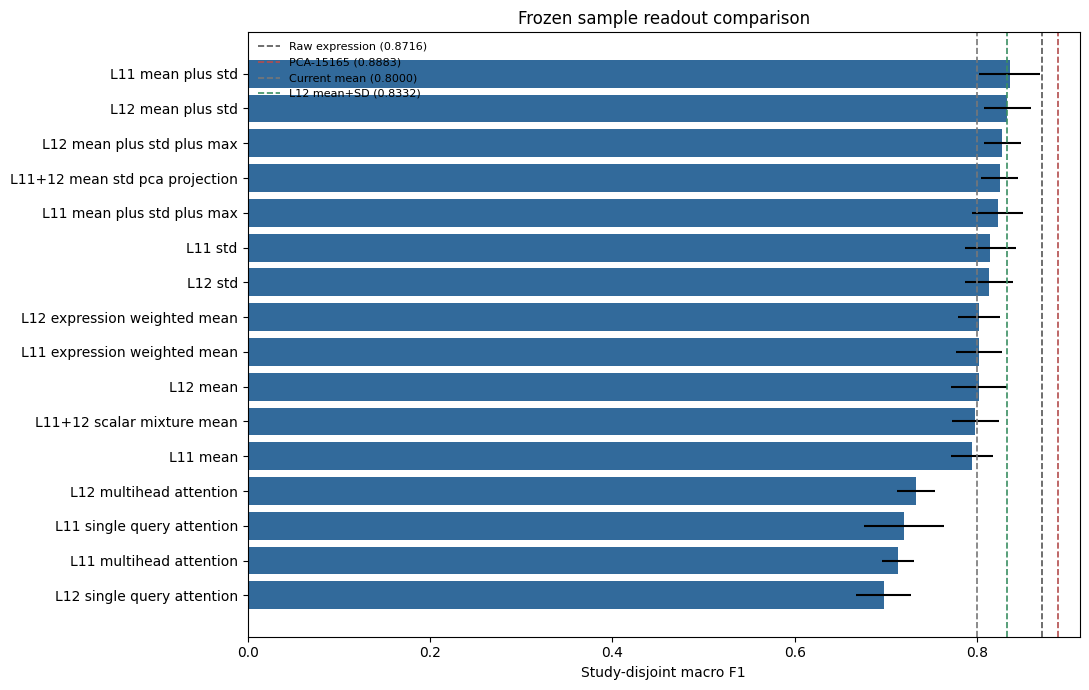

In [3]:
ranking=pd.read_csv(RESULTS/'ranked_summary.csv')
display(ranking.style.format(precision=4).hide(axis='index'))
fig,ax=plt.subplots(figsize=(11,7));q=ranking.sort_values('study_disjoint_f1')
labels=['L'+str(r.layer)+' '+str(r.readout).replace('_',' ') for _,r in q.iterrows()]
ax.barh(labels,q.study_disjoint_f1,xerr=q.f1_sd,color='#326a9b')
for x,label,color in [(0.8716,'Raw expression','#555555'),(0.8883,'PCA-15165','#b34d4d'),(0.800,'Current mean','#777777'),(0.8332,'L12 mean+SD','#3b8f62')]:ax.axvline(x,ls='--',lw=1.2,color=color,label=f'{label} ({x:.4f})')
ax.set(xlabel='Study-disjoint macro F1',title='Frozen sample readout comparison');ax.legend(frameon=False,fontsize=8);fig.tight_layout();plt.show()

## Representation geometry

Tissue and study 10-neighbor purity are complementary diagnostics. A desirable readout improves tissue neighborhoods without merely tightening study-specific neighborhoods. Effective dimensionality is summarized using participation ratio and PC1+PC2 variance.

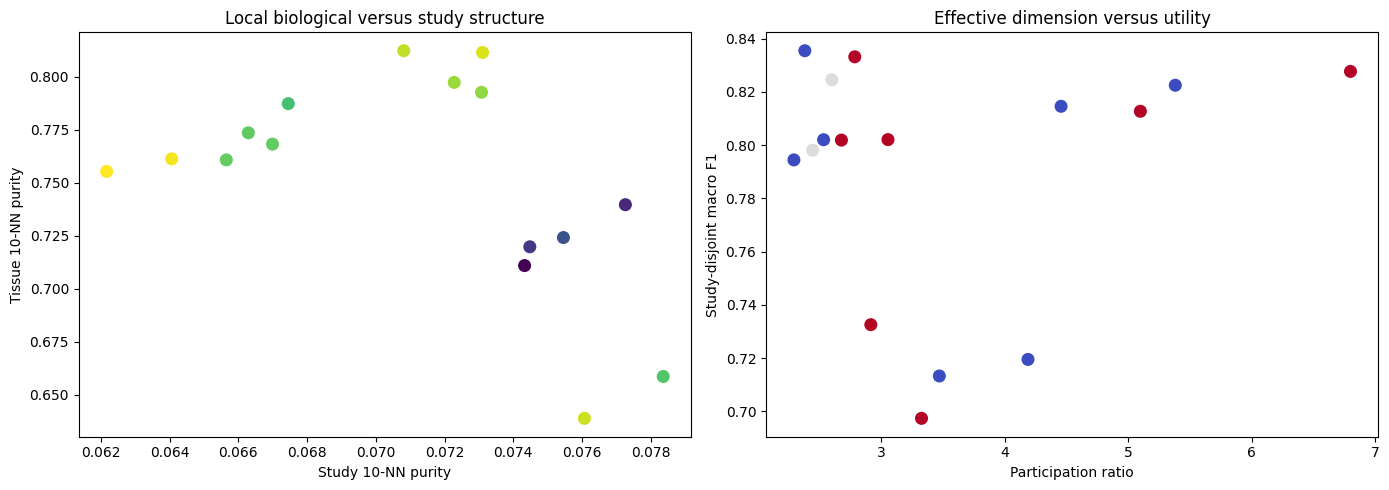

In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(ranking.study_10nn_purity,ranking.tissue_10nn_purity,c=ranking.study_disjoint_f1,cmap='viridis',s=70)
axes[0].set(xlabel='Study 10-NN purity',ylabel='Tissue 10-NN purity',title='Local biological versus study structure')
layer_color=ranking.layer.astype(str).map({'11':11,'12':12,'11+12':11.5}).astype(float)
axes[1].scatter(ranking.participation_ratio,ranking.study_disjoint_f1,c=layer_color,cmap='coolwarm',s=70)
axes[1].set(xlabel='Participation ratio',ylabel='Study-disjoint macro F1',title='Effective dimension versus utility');fig.tight_layout();plt.show()

## OSDR response-geometry safety check

The strongest readouts are applied to the unchanged strict RR1/RR3 technical-remeasurement contrasts. Selection does not use these OSDR outcomes. The key safeguards are preserving the real RR1 reversal, retaining strong RR3 replication, and avoiding increased RR1↔RR3-39 false similarity.

readout,RR1_cosine,RR1_spearman,RR3_39_cosine,RR3_39_spearman,RR3_40_cosine,RR3_40_spearman,false_friend_cosine,false_friend_spearman
current_layer12_mean,-0.8067,-0.1663,0.7900,0.5087,0.9166,0.8783,0.8108,0.4427
layer11_mean_plus_std,-0.8440,-0.6827,0.8664,0.7661,0.9183,0.8918,0.8597,0.7579
layer11_multihead_attention,-0.4545,0.3284,0.4343,0.3852,0.8977,0.8859,0.4645,0.1290
layer11_single_query_attention,-0.2094,0.4316,0.5851,0.5631,0.8050,0.7887,0.2754,-0.0572
layer12_mean_plus_std,-0.7881,-0.6398,0.7667,0.6218,0.9141,0.8776,0.7953,0.6660
layer12_multihead_attention,-0.2457,0.3975,0.0327,0.0301,0.7052,0.7198,0.3355,0.1768
layer12_single_query_attention,-0.1333,0.4495,0.1129,0.1063,0.5022,0.5252,0.2364,0.0810


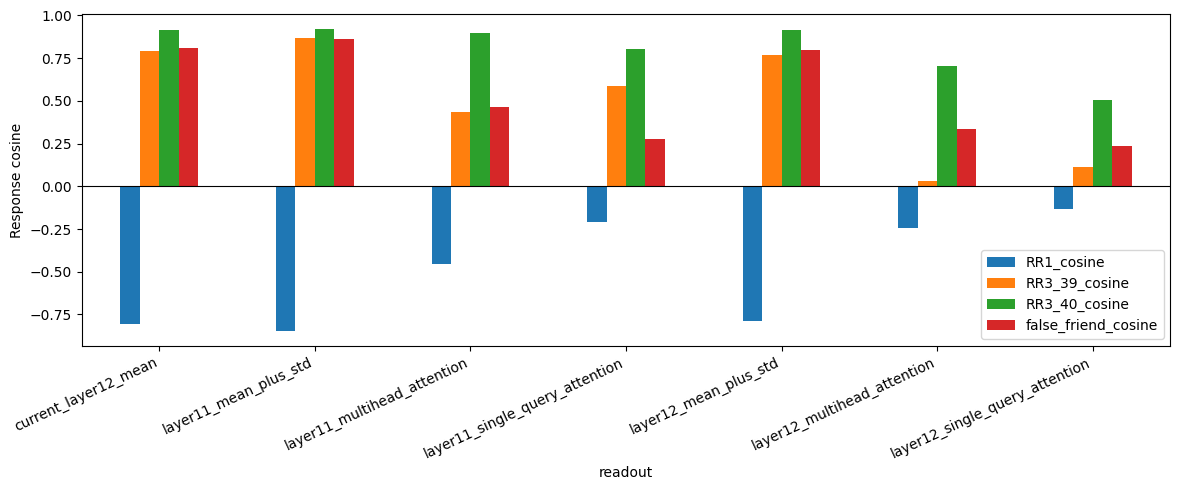

In [5]:
path=RESULTS/'response_geometry_summary.csv'
if path.exists():
    response=pd.read_csv(path);display(response.style.format(precision=4).hide(axis='index'))
    response.set_index('readout')[['RR1_cosine','RR3_39_cosine','RR3_40_cosine','false_friend_cosine']].plot.bar(figsize=(12,5));plt.axhline(0,color='black',lw=.8);plt.ylabel('Response cosine');plt.xticks(rotation=25,ha='right');plt.tight_layout();plt.show()
else: print('Response-geometry results are generated after trainable readouts finish.')

## Conclusion

The selected readout is determined jointly from held-out tissue utility and response-geometry behavior. Improvement over mean pooling is interpreted as recoverable readout loss; failure to reach raw expression or PCA indicates remaining backbone/representation loss. OSDR checks prevent a tissue-optimized readout from being presented as generally superior if it conceals known technical sensitivity or amplifies a known false friend.

## Task-agnostic frozen readouts

This extension tests whether predefined biological modules or BridgeRNA's own frozen attention expose information hidden by global averaging. No new pooling head is learned.

**Ditto-style attention.** BridgeRNA has no CLS token and its fused attention operation does not return a full attention matrix. We reconstruct weights from the frozen Q/K projections in two prespecified ways: (1) mean attention received from 64 evenly spaced query genes across all eight heads, and (2) attention from the mean query vector of each head to all keys, averaged across heads. The resulting gene weights pool the output tokens from the same layer.

**Module pooling.** Each of the 50 MSigDB Hallmark sets is mapped into the canonical 15,165-gene order. Per-module contextual-token means are concatenated and retained as a 25,600-D representation; module mean+SD retains both summaries as 51,200 dimensions. Hallmark overlap is intentionally preserved.

**Fixed cross-layer combinations.** Equal-weight layer-11/layer-12 mean+SD and direct concatenation are label-free. All downstream classifiers still use the exact five GSE-disjoint folds.

In [6]:
task_dir=RESULTS/'task_agnostic'
task=pd.read_csv(task_dir/'task_agnostic_ranked_summary.csv')
response_task=pd.read_csv(task_dir/'response_geometry_summary.csv')
display(task.style.format(precision=4).hide(axis='index'))
display(response_task.style.format(precision=4).hide(axis='index'))

readout,dimensions,study_disjoint_f1,f1_sd,balanced_accuracy,PC1_2,participation_ratio,tissue_10nn_purity,study_10nn_purity
L12_hallmark_module_mean_std,51200,0.8810,0.0268,0.8768,0.6096,3.7274,0.7881,0.0667
L11_hallmark_module_mean_std,51200,0.8783,0.0326,0.8752,0.6520,3.0775,0.7813,0.0657
L12_hallmark_module_mean,25600,0.8568,0.0184,0.8646,0.6295,3.4474,0.7843,0.0663
L11_hallmark_module_mean,25600,0.8495,0.0239,0.8627,0.6729,2.8570,0.7785,0.0653
L11_L12_concat_mean_std,2048,0.8431,0.0322,0.8588,0.6991,2.5855,0.7700,0.0641
L12_mean_std,1024,0.8348,0.0247,0.8532,0.6788,2.7860,0.7716,0.0648
L11_L12_equal_mean_std,1024,0.8335,0.0354,0.8576,0.7122,2.4488,0.7698,0.0638
L11_mean_std,1024,0.8317,0.0315,0.8511,0.7261,2.3813,0.7680,0.0634
L12_ditto_sampled_incoming,512,0.8055,0.0229,0.8386,0.6696,2.9134,0.7756,0.0650
L12_ditto_centroid_query,512,0.8031,0.0279,0.8370,0.6670,2.9350,0.7744,0.0648


readout,RR1_cosine,RR3_39_cosine,RR3_40_cosine,false_friend_cosine
current_mean,-0.8067,0.7900,0.9166,0.8108
L11_ditto_sampled_incoming,-0.8512,0.8632,0.9314,0.8635
L11_ditto_centroid_query,-0.8562,0.9263,0.9417,0.9015
L11_hallmark_module_mean,-0.7225,0.8671,0.9256,0.7058
L11_hallmark_module_mean_std,-0.6778,0.8434,0.9137,0.6643
L12_ditto_sampled_incoming,-0.7853,0.6597,0.9266,0.7463
L12_ditto_centroid_query,-0.8033,0.8346,0.9224,0.8052
L12_hallmark_module_mean,-0.4995,0.7916,0.9328,0.5627
L12_hallmark_module_mean_std,-0.4237,0.7751,0.9224,0.5099
L11_L12_equal_ditto_sampled,-0.8390,0.7875,0.9312,0.8243


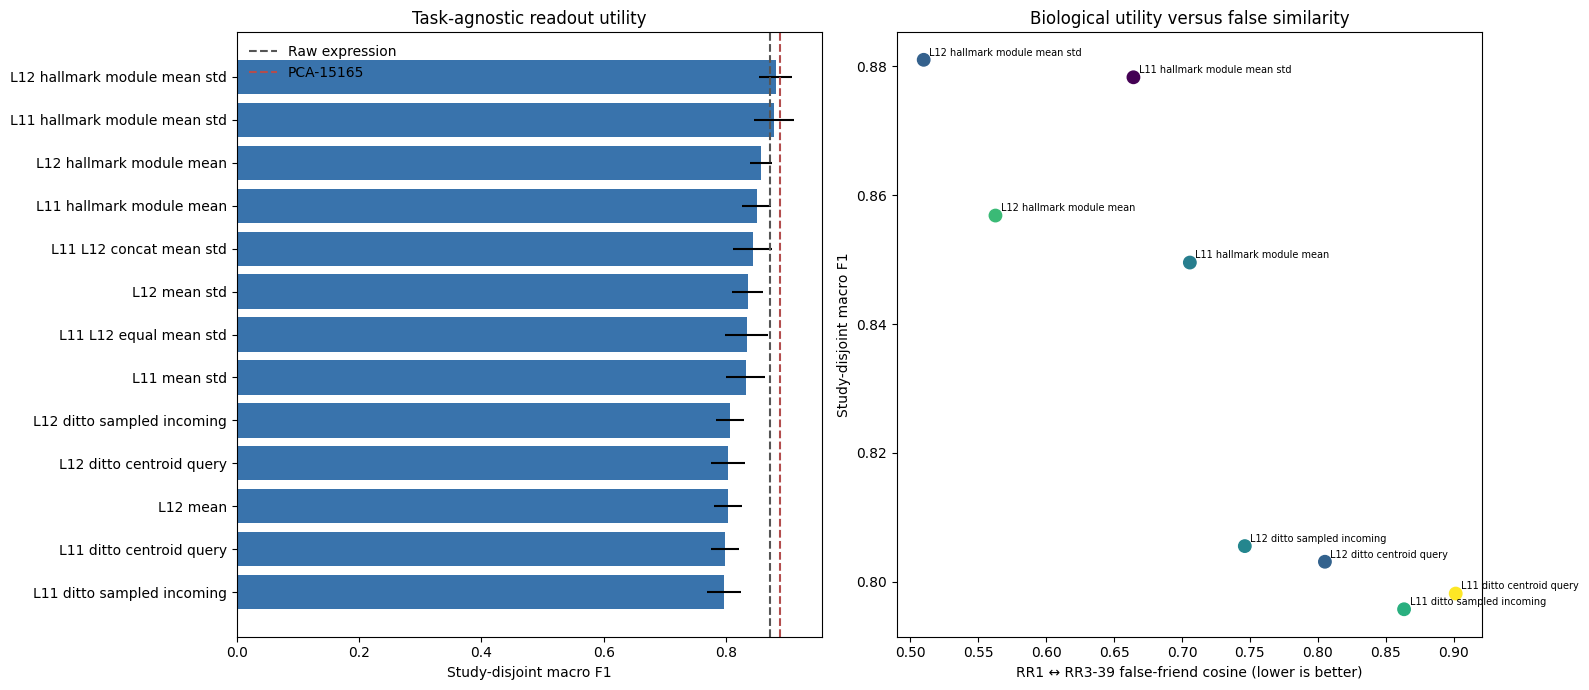

In [7]:
fig,axes=plt.subplots(1,2,figsize=(16,7))
q=task.sort_values('study_disjoint_f1')
axes[0].barh(q.readout.str.replace('_',' '),q.study_disjoint_f1,xerr=q.f1_sd,color='#3973ac')
axes[0].axvline(.8716,ls='--',color='#555',label='Raw expression')
axes[0].axvline(.8883,ls='--',color='#b34d4d',label='PCA-15165')
axes[0].set(xlabel='Study-disjoint macro F1',title='Task-agnostic readout utility');axes[0].legend(frameon=False)
merged=task.merge(response_task,on='readout',how='inner')
axes[1].scatter(merged.false_friend_cosine,merged.study_disjoint_f1,s=80,c=merged.RR3_40_cosine,cmap='viridis')
for _,r in merged.iterrows():axes[1].annotate(r.readout.replace('_',' '),(r.false_friend_cosine,r.study_disjoint_f1),fontsize=7,xytext=(4,3),textcoords='offset points')
axes[1].set(xlabel='RR1 ↔ RR3-39 false-friend cosine (lower is better)',ylabel='Study-disjoint macro F1',title='Biological utility versus false similarity')
fig.tight_layout();plt.show()

### Task-agnostic conclusion

Layer-12 Hallmark module mean+SD is the strongest task-agnostic frozen readout in this benchmark. It reaches **0.8810 ± 0.0268 macro F1**, exceeding raw expression (0.8716) and approaching PCA (0.8883). It also raises tissue 10-NN purity to 0.788 and reduces the RR1↔RR3-39 false-friend cosine from 0.811 to **0.510**, while RR3-39 and RR3-40 remain concordant (0.775 and 0.922). RR1 remains negative but its reversal is attenuated from −0.807 to −0.424; this must be reported rather than described as invariance.

Module means alone are weaker (0.857) but also reduce false similarity. Frozen Ditto-style attention provides essentially no tissue improvement over mean pooling and often increases false similarity, particularly at layer 11. Simple layer concatenation gives a modest result (0.843) but does not approach module pooling.

The main positive result is therefore **module preservation rather than attention reweighting**: retaining 50 separate biological summaries recovers information lost by one global mean. Important limitations are that the winning representation is 51,200-D, Hallmark genes overlap across modules, effective dimensionality remains low (participation ratio 3.73), and the tissue advantage over raw/PCA is small relative to fold variability. This supports a task-agnostic readout improvement, not a claim that the frozen representation universally outperforms expression.

# General validation of contextual-gene graph fingerprints

This validation was completed **before loading RR1/RR3 graph outcomes**. Each sample is a graph over the fixed 15,165 genes using frozen layer-12 contextual embeddings. Directed edges join each gene to its exact top-k cosine neighbors. The primary graph is union-symmetrized k=10; k=5/20 and mutual-kNN are fixed sensitivities.

The graph is not collapsed to one adjacency cosine. We retain edge Jaccard, mean per-gene neighborhood Jaccard, weighted overlap/correlation, Louvain community agreement, and a 20-eigenvalue normalized-adjacency spectrum. Degree+strength is used only as a graph-derived tissue-classifier profile.

In [8]:
graph_general=RESULTS/'graph_fingerprint/general_validation'
general=pd.read_csv(graph_general/'general_validation_summary.csv')
retrieval=pd.read_csv(graph_general/'technical_retrieval_summary.csv')
tissue_pairs=pd.read_parquet(graph_general/'tissue_pair_similarity.parquet')
functional=pd.read_csv(graph_general/'functional_edge_null.csv')
display(general.style.format(precision=4).hide(axis='index'))
display(retrieval.style.format({'R@1':'{:.1%}','R@5':'{:.1%}','median_rank':'{:.1f}'}).hide(axis='index'))

domain,metric,value,secondary,detail
technical retrieval,edge_jaccard,0.9250,0.9625,median rank 1
technical retrieval,weight_correlation,0.9625,0.9875,median rank 1
technical retrieval,weighted_overlap,0.9000,0.9875,median rank 1
technical retrieval,neighborhood_jaccard,0.9125,0.9625,median rank 1
tissue,study-disjoint graph macro F1,0.8616,0.0287,mean ± SD across 5 folds
tissue,same/different edge-Jaccard ratio,2.2949,nan,"1,000 prespecified study-separated pairs"
community,same-pair minus unrelated ARI,-0.0060,nan,median; no positive discrimination
nan,independent identity-shuffle R@1,0.0000,0.0500,R@1 / R@5
perturbation,replicate vs unrelated edge-Jaccard difference,0.2436,nan,biological replicate minus unrelated


k,graph,metric,queries,R@1,R@5,median_rank
5,union,edge_jaccard,80,93.8%,96.2%,1.0
5,union,weight_correlation,80,93.8%,98.8%,1.0
5,union,weighted_overlap,80,92.5%,98.8%,1.0
5,union,neighborhood_jaccard,80,91.2%,96.2%,1.0
5,mutual,edge_jaccard,80,85.0%,96.2%,1.0
5,mutual,weight_correlation,80,91.2%,97.5%,1.0
5,mutual,weighted_overlap,80,85.0%,96.2%,1.0
10,union,edge_jaccard,80,92.5%,96.2%,1.0
10,union,weight_correlation,80,96.2%,98.8%,1.0
10,union,weighted_overlap,80,90.0%,98.8%,1.0


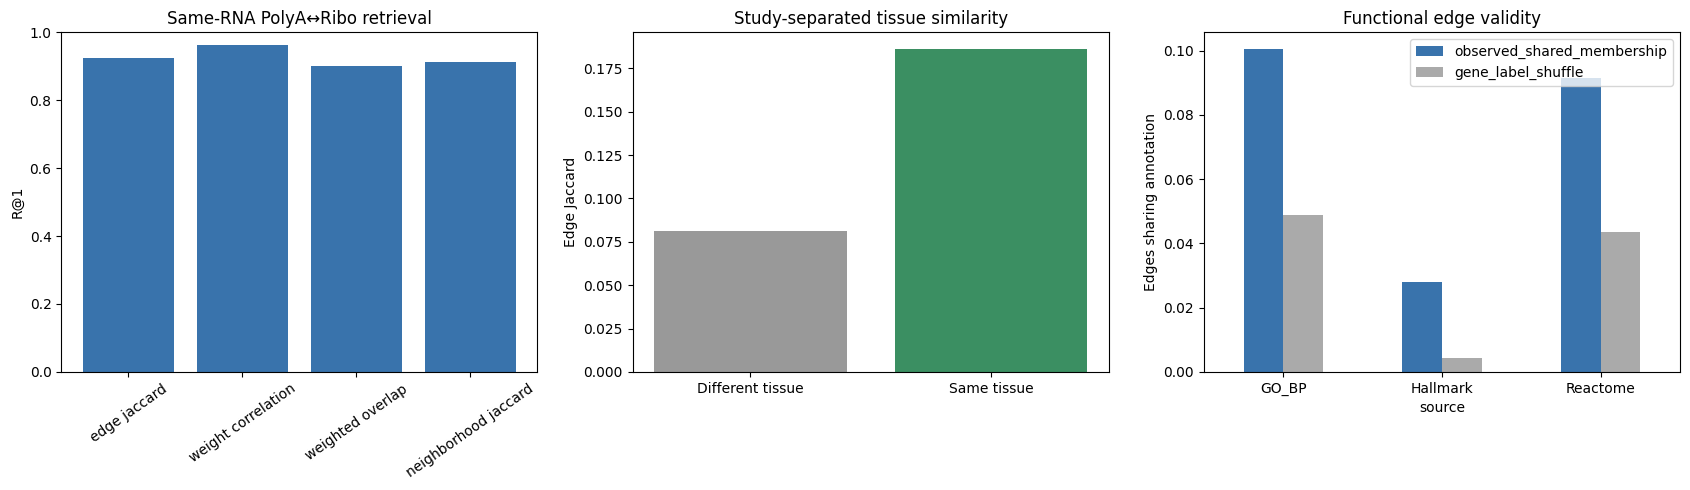

In [9]:
figdir=RESULTS/'graph_fingerprint/figures';figdir.mkdir(parents=True,exist_ok=True)
fig,axes=plt.subplots(1,3,figsize=(17,5));primary=retrieval[(retrieval.k==10)&(retrieval.graph=='union')]
axes[0].bar(primary.metric.str.replace('_',' '),primary['R@1'],color='#3973ac');axes[0].set(ylim=(0,1),ylabel='R@1',title='Same-RNA PolyA↔Ribo retrieval');axes[0].tick_params(axis='x',rotation=35)
q=tissue_pairs[tissue_pairs.k==10].groupby('same_tissue').edge_jaccard.mean();axes[1].bar(['Different tissue','Same tissue'],[q[False],q[True]],color=['#999','#3b8f62']);axes[1].set(ylabel='Edge Jaccard',title='Study-separated tissue similarity')
f=functional.groupby('source')[['observed_shared_membership','gene_label_shuffle']].mean();f.plot.bar(ax=axes[2],color=['#3973ac','#aaa']);axes[2].set(ylabel='Edges sharing annotation',title='Functional edge validity');axes[2].tick_params(axis='x',rotation=0);fig.tight_layout()
for ext in ['png','pdf']:fig.savefig(figdir/f'general_graph_validation.{ext}',dpi=400)
plt.show()

## General-validation findings

- Across 40 controlled same-RNA T-cell pairs, primary k=10 union graphs retrieve the opposite-library match at **R@1 92.5% by edge Jaccard, 96.3% by weighted-edge correlation, 90.0% by weighted overlap, and 91.3% by neighborhood Jaccard**; median rank is 1. Results remain similar at k=5/20 and under mutual-kNN.
- Graph degree+strength reaches **0.8616 ± 0.0287 study-disjoint tissue macro F1**: below raw (0.8716), Hallmark mean+SD (0.8810), and PCA (0.8883), but above Bridge mean (~0.800). Same-tissue study-separated graphs have 2.29-fold higher edge Jaccard than different-tissue graphs.
- Same-study/role exercise replicates have mean edge Jaccard 0.654 versus 0.410 for unrelated contrasts. The eight studies are all aerobic exercise, so modality-specific conclusions are unavailable.
- Edges share external annotations more often than gene-label shuffles: Hallmark 2.79% versus 0.43%, GO BP 10.06% versus 4.88%, and Reactome 9.14% versus 4.36%. No authoritative local PPI/regulatory resource was available.
- Independently shuffling contextual-gene identities reduces k=10 retrieval to **R@1 0%, R@5 5%**. Community partitions do not discriminate true pairs (median ARI 0.477 versus 0.483 unrelated), a clear negative result.

These outcomes freeze the graph parameters before NASA stress testing. Edge and neighborhood structure validate; community identity does not.

# Held-out RR1/RR3 graph stress tests

Only after general validation was frozen were RR1/RR3 loaded. Each signed graph-response profile is mean FLT weighted adjacency minus mean GC weighted adjacency. Because graph and vector metrics have different scales, ranking/discrimination is primary.

k,graph,comparison,signed_edge_cosine,signed_edge_correlation,edges_A,edges_B
10,union,RR1,0.1834,0.1849,204759,209271
10,union,RR3-39,0.3193,0.3192,163894,163303
10,union,RR3-40,0.3990,0.3990,160472,161860
10,union,RR1↔RR3-39 false friend,0.0118,0.0114,204759,163894


comparison,RR1,RR3-39,RR3-40,false_friend
representation,,,,
Bridge mean,-0.8067,0.7900,0.9166,0.8108
Graph signed-edge response,0.1834,0.3193,0.3990,0.0118
Hallmark mean+SD,-0.4237,0.7751,0.9224,0.5099
PCA-15165,-0.2062,0.7898,0.9141,0.3608
Raw expression,0.3692,0.6523,0.8224,0.1207


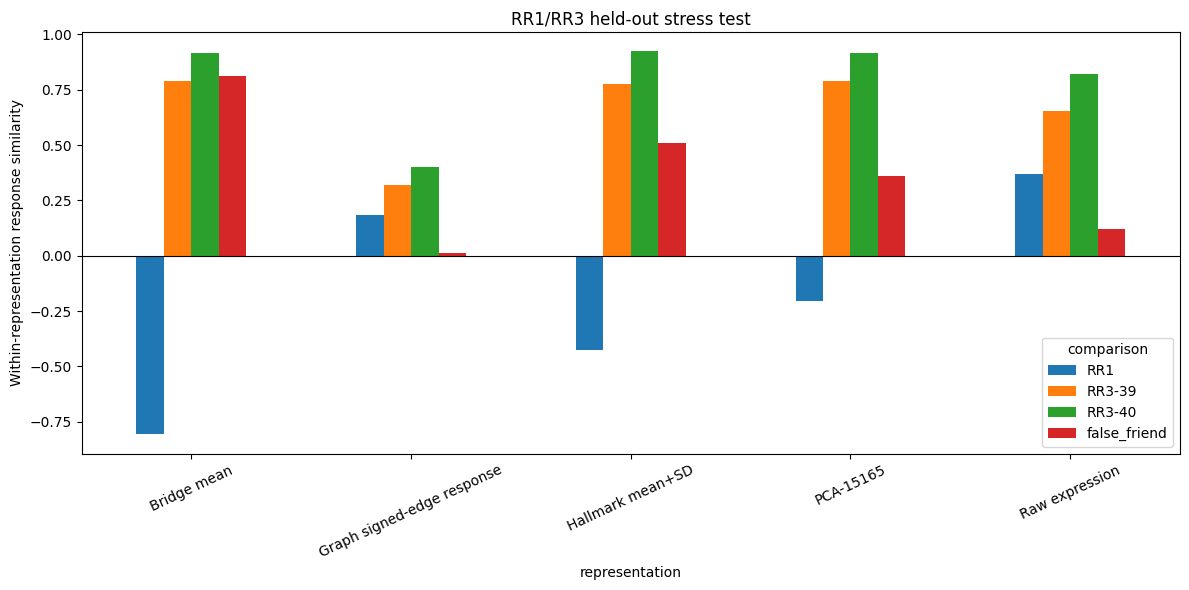

In [10]:
stress_dir=RESULTS/'graph_fingerprint/rr1_rr3_stress'
stress=pd.read_csv(stress_dir/'graph_response_stress_metrics.csv')
cross=pd.read_csv(stress_dir/'cross_representation_comparison.csv')
display(stress[(stress.k==10)&(stress.graph=='union')].style.format(precision=4).hide(axis='index'))
display(cross.pivot(index='representation',columns='comparison',values='similarity').style.format(precision=4))
fig,ax=plt.subplots(figsize=(12,6));pivot=cross.pivot(index='representation',columns='comparison',values='similarity');pivot.plot.bar(ax=ax);ax.axhline(0,color='black',lw=.8);ax.set(ylabel='Within-representation response similarity',title='RR1/RR3 held-out stress test');ax.tick_params(axis='x',rotation=25);fig.tight_layout()
for ext in ['png','pdf']:fig.savefig(figdir/f'rr1_rr3_graph_stress.{ext}',dpi=400)
plt.show()

## Graph conclusion

The primary graph response ranks the true replications above the false friend: RR3-40 **0.399**, RR3-39 **0.319**, RR1 **0.183**, and RR1↔RR3-39 false friend **0.012**. Unlike global Bridge mean, graph organization produces neither the strong false similarity (0.811) nor an RR1 reversal. Its ordering resembles raw expression while retaining a distinct contextual-graph definition.

This supports reproducible contextual organization lost through global pooling, but not universal graph superiority. Tissue F1 remains below PCA/Hallmark pooling, communities fail validation, RR1 graph replication is weak, and graph scores are not numerically interchangeable with vector cosine.